In [1]:
import pandas as pd
from collections import Counter
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import seaborn as sns
pd.set_option('chained_assignment',None)


In [2]:
parties = ['CDU/CSU', 'SPD','GRÜNE', 'FDP', 'AfD', 'DIE LINKE', 'fraktionslos']

In [3]:
df_interruptions = pd.read_csv('../_data/interruptions.csv')
df_interruptions.head(10)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
0,0,So kriegen Sie die Steuerlüge nicht aus der Welt!,DIE LINKE,Dr. B riefs,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
1,1,Bravo!,SPD,<unknown>,CDU/CSU,Dr. Theodor Waigel,1991-03-12,386,1
2,2,Das ist eine Frechheit!,DIE LINKE,<unknown>,CDU/CSU,Dr. Jürgen Rüttgers,1991-03-12,15,3
3,3,Gebt erst mal das Vermögen der DIE LINKE dem S...,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
4,4,Die DIE LINKE soll das Vermögen zurückgeben!,CDU/CSU,zu Bentrup,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
5,5,Wundert Sie das?,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
6,6,Der muß auch noch reden? Reicht denn nicht einer?,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
7,7,Das sagen Sie!,CDU/CSU,<unknown>,DIE LINKE,Dr. Ulrich Briefs,1991-03-12,127,7
8,8,Wohl wahr!,FDP,Dr. Graf Lambsdorff,FDP,Dr. Wolfgang Weng,1991-03-12,180,8
9,9,Haben Sie vergessen hinzuschauen?,SPD,<unknown>,FDP,Dr. Wolfgang Weng,1991-03-12,180,8


Einige (wenige) Felder sind leider leer aus den Protokollen geparst worden. Die nehmen wir jetzt heraus.

In [4]:
non_string_entries = df_interruptions['comment_text'].apply(lambda x: not isinstance(x, str))
df_interruptions[non_string_entries]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
12390,12390,NaN,CDU/CSU,<unknown>,SPD,Jan Oostergetelo,1992-06-24,75,8680
16448,16448,NaN,CDU/CSU,Bartholomäus Kalb,CDU/CSU,Manfred Kolbe,1992-11-26,87,11497
46782,46782,NaN,FDP,Dr. Klaus Röhl,SPD,Ursula Burchardt,1996-04-24,38,35073
84853,84853,NaN,CDU/CSU,Norbert Geis,SPD,Hermann Bachmaier,2000-03-23,33,58190
84956,84956,NaN,SPD,Ludwig Stiegler,CDU/CSU,Dr. Norbert Lammert,2000-03-24,58,58216
87884,87884,NaN,FDP,Hans-Michael Goldmann,FDP,Marita Sehn,2000-06-29,33,59633
336942,336942,NaN,FDP,Benjamin Strasser,SPD,Dr. Lars Castellucci,2017-12-13,50,168436
391870,391870,NaN,AfD,Marc Bernhard,AfD,Marc Bernhard,2020-11-26,34,195772
413810,413810,NaN,AfD,Jörn König,AfD,Jörn König,2022-06-23,39,208555
418533,418533,NaN,DIE LINKE,Dr. Petra Sitte,SPD,Simona Koß,2022-09-23,37,210112


In [5]:
df_interruptions= df_interruptions[~non_string_entries]

In [6]:
texts_per_party = df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: ' '.join(x))

In [113]:
texts_per_party_lists = []
df_interruptions.groupby('comment_party')['comment_text'].apply(lambda x: texts_per_party_lists.append(x.to_list()))
for l in texts_per_party_lists:
    print (len(l))

30467
135871
40826
71448
74820
120465
81


In [8]:
texts_per_party

comment_party
AfD             Ha, ha, ha! Das ist nicht unser Problem! Ui, d...
CDU/CSU         Gebt erst mal das Vermögen der DIE LINKE dem S...
DIE LINKE       So kriegen Sie die Steuerlüge nicht aus der We...
FDP             Wohl wahr! Verfassungswidrig! Unfug! Wofür sol...
GRÜNE           Das ist Rea -lität! Sie fielen gestern im Plen...
SPD             Bravo! Haben Sie vergessen hinzuschauen? Sind ...
fraktionslos    Bei Wechsel der Verhältnisse! Er ist trotz dem...
Name: comment_text, dtype: object

In [9]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Robin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [10]:
tokenizer = nltk.data.load("tokenizers/punkt/german.pickle")

In [11]:

def get_ngrams(text, n):
    tokens = word_tokenize(text, language = 'german')
    return list(ngrams(tokens, n))

ngrams_data = {}
for party, text in texts_per_party.items():
    print(party)
    unigrams = get_ngrams(text, 1)
    bigrams = get_ngrams(text, 2)
    trigrams = get_ngrams(text, 3)
    
    ngrams_data[party] = {
        'unigrams': Counter(unigrams),
        'bigrams': Counter(bigrams),
        'trigrams': Counter(trigrams)
    }

AfD
CDU/CSU


KeyboardInterrupt: 

In [ ]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('ichglaubejedenscheiss.de', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
468848,468848,www.ichglaubejedenscheiss.de!,AfD,Martin Reichardt,SPD,Josephine Ortleb,2024-03-15,34,226365


In [ ]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Naturschutzzerstörungsfraktion', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
400588,400588,Die Naturschutzzerstörungsfraktion seid ihr!,AfD,Karsten Hilse,GRÜNE,Steffi Lemke,2021-05-20,37,201649


In [ ]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Verschwörungstheoretiker', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
319472,319472,Alles Verschwörungstheoretiker!,GRÜNE,Sylvia Kotting-Uhl,SPD,Klaus Barthel,2016-05-11,77,159690
344422,344422,Von anderen Verschwörungstheoretikern!,FDP,Konstantin Kuhle,AfD,Stephan Brandner,2018-06-14,50,172617
353754,353754,Verschwörungstheoretiker!,SPD,<unknown>,AfD,Armin-Paulus Hampel,2018-11-30,51,176789
354735,354735,Die Krise ist ja nicht weg! Verschwörungstheor...,AfD,Leif-Erik Holm,SPD,Metin Hakverdi,2018-12-13,61,177210
361252,361252,Verschwörungstheoretiker!,AfD,Jörg Schneider,FDP,Konstantin Kuhle,2019-04-05,17,180501
381399,381399,Verschwörungstheoretiker!,AfD,Stephan Brandner,CDU/CSU,Philipp Amthor,2020-05-07,91,189894
381451,381451,So ein Quatsch! Verschwörungstheoretiker! Setz...,CDU/CSU,Tino Sorge,AfD,Detlev Spangenberg,2020-05-07,70,189911
383542,383542,Sie laufen ja lieber bei Verschwörungstheoreti...,SPD,Timon Gremmels,AfD,Andreas Bleck,2020-05-29,44,191019
385476,385476,Uns als Verschwörungstheoretiker zu bezeichnen...,DIE LINKE,Evrim Sommer,FDP,Ulrich Lechte,2020-07-03,42,192179
400246,400246,Das sagen alle Verschwörungstheoretiker!,AfD,Elsner von Gronow,SPD,Dr. Karl-Heinz Brunner,2021-05-07,40,201330


In [ ]:
df_interruptions.loc[df_interruptions['comment_text'].str.contains('Landschaftsverschandelung', na=False)]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
388048,388048,Landschaftsverschandelung ist das!,AfD,Dr. Götz Frömming,SPD,Yasmin Fahimi,2020-10-01,45,193494


In [12]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*\.de.*|.*\.com.*|www\..*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
252036,252036,Das kann wohl nicht wahr sein!)Die Verbraucher...,CDU/CSU,<unknown>,SPD,Elvira Drobinski-Weiß,2011-09-08,65,126728
332168,332168,Ich empfehle www.linksfraktion.de !,DIE LINKE,Matthias W. Birkwald,SPD,Mechthild Rawert,2017-03-31,57,166054
468848,468848,www.ichglaubejedenscheiss.de!,AfD,Martin Reichardt,SPD,Josephine Ortleb,2024-03-15,34,226365
469427,469427,chefkoch.de!,AfD,Beatrix von Storch,SPD,Dr. Jens Zimmermann,2024-03-21,51,226645
469451,469451,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226652
469452,469452,Für chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226652
469453,469453,chefkoch.de!,AfD,Beatrix von Storch,FDP,Maximilian Funke-Kaiser,2024-03-21,8,226652


In [13]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Zwischenruf.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
395,395,Aber Zwischenrufe sind erlaubt!,CDU/CSU,Gerhard Reddemann,SPD,Dr. Wilfried Penner,1991-04-18,8,717
1425,1425,"„Uns ken nen alle"" war der Zwischenruf des Kol...",CDU/CSU,Bartholomäus Kalb,CDU/CSU,Irmgard Karwatzki,1991-06-04,58,1380
1595,1595,Der Zwischenruf des Jahres!,SPD,fried Penner,FDP,Ina Albowitz,1991-06-05,133,1453
3689,3689,Zwischenrufe nie!,SPD,Gerd Andres,CDU/CSU,Arnulf Kriedner,1991-09-05,76,2669
4086,4086,"Das war keine Frage, das war nur ein Zwischenruf!",SPD,Peter Conradi,SPD,Dorle Marx,1991-09-19,7,2909
...,...,...,...,...,...,...,...,...,...
456118,456118,Zwischenrufe sind zulässig!,AfD,Enrico Komning,GRÜNE,Dr. Till Steffen,2023-11-09,38,222627
462499,462499,"Das zeigt mal wieder, wo Sie hängen geblieben ...",GRÜNE,Tobias B. Bacherle,AfD,Dr. Gottfried Curio,2023-12-15,61,224445
464972,464972,"Das ist so unterkomplex, da kann man nicht in ...",SPD,Dr. Wiebke Esdar,CDU/CSU,Thomas Jarzombek,2024-01-30,60,225111
468320,468320,Da wäre der Zwischenruf „Fake News“ noch ein E...,SPD,Sebastian Hartmann,CDU/CSU,Andrea Lindholz,2024-03-14,86,226229


Da fallen einem schon keine Zwischenrufe mehr ein, so absurd ist das!

In [14]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Das ist viel zu billig.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
157592,157592,Das ist viel zu billig! So billig sind Sie doc...,CDU/CSU,Michael Glos,SPD,Gerhard Schröder,2004-11-24,354,83952


In [15]:
df_interruptions.loc[df_interruptions['comment_text'].apply(lambda x: bool(re.search(r'.*Die Sendung mit der Maus.*', str(x), flags= re.UNICODE|re.IGNORECASE)))]

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
376982,376982,„Die Sendung mit der Maus“!,CDU/CSU,Dr. Georg Nüßlein,DIE LINKE,Gösta Beutin,2020-01-17,62,187462
429162,429162,"Ja, das ist genau Ihr intellektuelles Niveau: ...",AfD,Martin Reichardt,DIE LINKE,Heidi Reichinnek,2022-12-15,34,213384


In [16]:

for party, ngram_counts in ngrams_data.items():
    print(f"Partei: {party}")
    print(f"Häufigste unigramme:{ ngram_counts['unigrams'].most_common(10)}")
    print(f"Häufigste bigramme: {ngram_counts['bigrams'].most_common(10)}")
    print(f"Häufigste trigramme: {ngram_counts['trigrams'].most_common(10)}")
    print()

Partei: AfD
Häufigste unigramme:[(('!',), 34091), (('Sie',), 8530), ((',',), 6802), (('Das',), 5537), (('?',), 4729), (('ist',), 4576), (('nicht',), 4005), (('die',), 3528), (('das',), 2966), (('doch',), 2784)]
Häufigste bigramme: [(('!', 'Das'), 4894), (('Das', 'ist'), 2274), (('!', 'Sie'), 2247), (('!', 'Die'), 1303), (('nicht', '!'), 1198), (('!', 'Ja'), 1026), (('!', 'Was'), 840), (('Ja', ','), 787), ((',', 'Herr'), 730), (('!', 'Wir'), 727)]
Häufigste trigramme: [(('!', 'Das', 'ist'), 2004), (('!', 'Ja', ','), 703), (('!', 'Sie', 'haben'), 519), (('!', 'Hört', '!'), 429), (('Das', 'ist', 'doch'), 397), (('!', 'Genau', '!'), 372), (('!', 'Ja', '!'), 308), (('!', 'Sie', 'sind'), 280), (('?', 'Das', 'ist'), 258), (('!', 'Das', 'war'), 252)]



Anscheinend ist das '!' sehr hoch im Kurs. Wie viel Prozent der Unterbrechungen enthalten denn ein Ausrufezeichen? 

In [17]:
percentage_excl_marks = df_interruptions['comment_text'].apply(lambda x:'!' in x).sum()/len(df_interruptions)*100
print(f"{percentage_excl_marks:.2f} %")

88.37 %


Die Kommentatoren wollen sich anscheinend Ausdruck verleihen. Sonst würden sie ja niemanden unterbrechen...

# Wordclouds

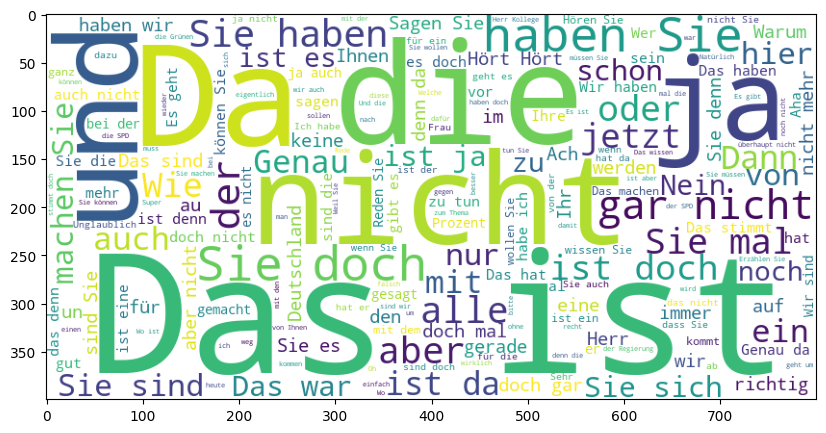

In [18]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texts_per_party['AfD'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Jetzt noch mit Stopwords, damit die Ansicht aussagekräftiger wird...

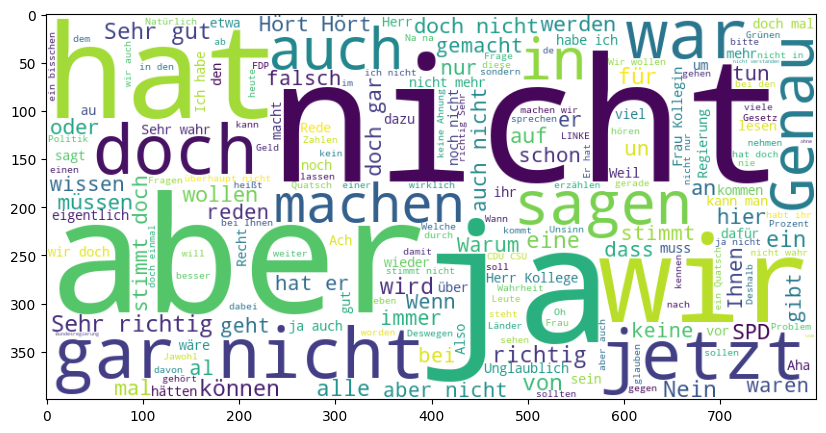

In [19]:
stopwords = ['Da', 'Sie', 'die', 'Das', 'ist', 'und', 'Dann', 'Wer', 'Wo', 'mit', 'gesagt', 'Was', 'sind', 'denn', 'haben', 'e', 'zu', 'sich', 'Ihre', 'der', 'es', 'So', 'Wie']
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords).generate(texts_per_party['CDU/CSU'])

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)

Die Wortfolge Hört Hört ist wohl ziemlich beliebt...

In [20]:
df_hoert_hoert = df_interruptions[df_interruptions['comment_text'].apply(lambda x: bool(re.search('hört.* hört.*', x, flags= re.UNICODE|re.IGNORECASE)))]
df_hoert_hoert.head(5)

,Unnamed: 0,comment_text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_len_sents,speech_id
324,324,Hört! Hört!,SPD,<unknown>,SPD,Ingrid Matthäus-Maier,1991-04-17,48,703
391,391,Hört! Hört!,CDU/CSU,Arnulf Kriedner,CDU/CSU,Dr. Gero Pfennig,1991-04-17,36,715
425,425,Hört! Hört!,FDP,<unknown>,CDU/CSU,Dr. Angela Merkel,1991-04-18,81,739
470,470,Hört! Hört! Da wer-den wir aufpassen!,SPD,Dr. Uwe Küster,CDU/CSU,Susanne Rahardt-Vahldieck,1991-04-18,65,754
510,510,Hört! Hört!,CDU/CSU,Peter Kittelmann,CDU/CSU,Horst Eylmann,1991-04-18,45,799


Party: AfD
  Lexical Diversity: 0.0659

Party: CDU/CSU
  Lexical Diversity: 0.0403

Party: DIE LINKE
  Lexical Diversity: 0.0608

Party: FDP
  Lexical Diversity: 0.0512

Party: GRÜNE
  Lexical Diversity: 0.0473

Party: SPD
  Lexical Diversity: 0.0438

Party: fraktionslos
  Lexical Diversity: 0.4695



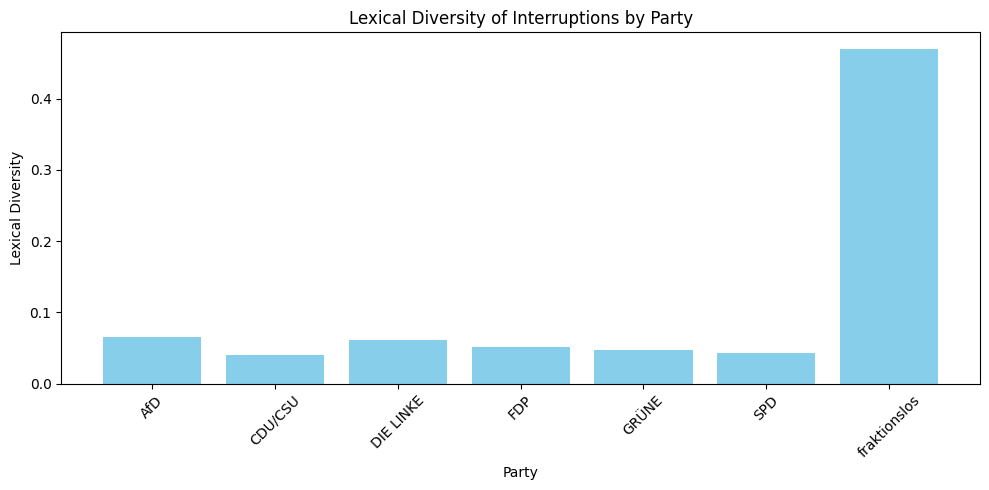

In [21]:
# Calculate lexical diversity
def lexical_diversity(text):
    tokens = word_tokenize(text, language='german')
    unique_tokens = set(tokens)
    return len(unique_tokens) / len(tokens)

# Calculate lexical diversity for each party
lexical_diversities = {}
for party, text in texts_per_party.items():
    diversity = lexical_diversity(text)
    lexical_diversities[party] = diversity

# Display lexical diversity results
for party, diversity in lexical_diversities.items():
    print(f"Party: {party}")
    print(f"  Lexical Diversity: {diversity:.4f}")
    print()

# Plot lexical diversity
plt.figure(figsize=(10, 5))
plt.bar(lexical_diversities.keys(), lexical_diversities.values(), color='skyblue')
plt.xlabel('Party')
plt.ylabel('Lexical Diversity')
plt.title('Lexical Diversity of Interruptions by Party')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

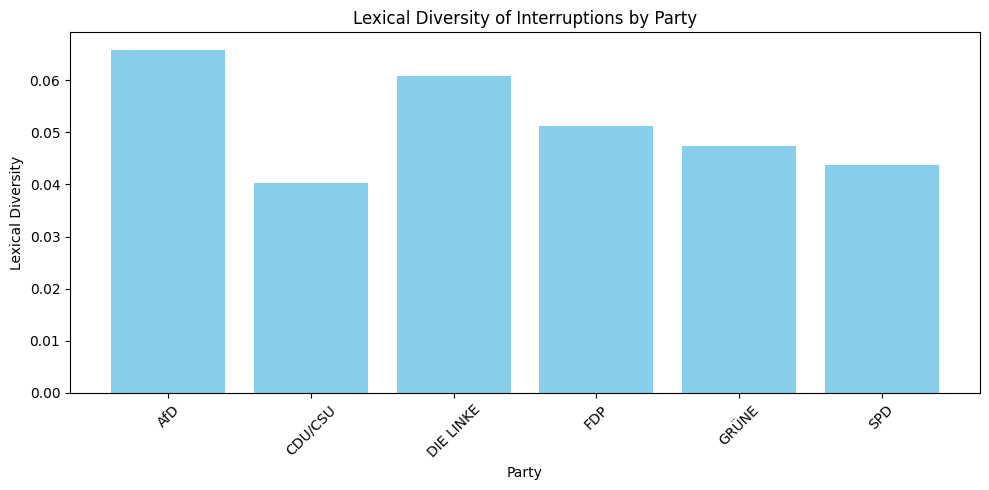

In [22]:
# Plot lexical diversity
plt.figure(figsize=(10, 5))
lexical_diversities.pop('fraktionslos')
plt.bar(lexical_diversities.keys(), lexical_diversities.values(), color='skyblue')
plt.xlabel('Party')
plt.ylabel('Lexical Diversity')
plt.title('Lexical Diversity of Interruptions by Party')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TFIDF

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as  np

In [114]:
print(type(texts_per_party_lists[0]))

<class 'list'>


In [136]:
print(texts_per_party_lists[0][:10])

['Ha, ha, ha!', 'Das ist nicht unser Problem!', 'Ui, das ist hart!', 'Super!', 'Warum denn?', 'Also geben Sie es auch noch zu!', 'Sie kennen doch gar nicht die Rechtslage!', 'Das ist der Geist der SED, der da steht!', 'Sie brechen sie doch!', 'Sie brechen diese Verträge!']


In [116]:
file_path = '../_data/stop_words_german.txt'

# Read the stopwords from the file into a list
with open(file_path, 'r', encoding='utf-8') as file:
    stop_words = [line.strip() for line in file if line.strip()]

stop_words.extend(['herr', 'frau','mal', 'reden'])

In [134]:
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, min_df=3, max_df=0.4)
tfidf_vecs_parties =[]
features_names_parties = []
for party_texts in texts_per_party_lists:
    tfidf_vec = vectorizer.fit_transform(party_texts)
    feature_names = vectorizer.get_feature_names_out()
    tfidf_vecs_parties.append(tfidf_vec)
    features_names_parties.append(feature_names)

for i, (party_tfidf, party_feature_names) in enumerate(zip(tfidf_vecs_parties, features_names_parties)):
    # Convert the tfidf vector to an array
    party_tfidf_array = party_tfidf.toarray()
    
    # Sum the tfidf values for each word across all documents for the party
    sum_tfidf_values = party_tfidf_array.sum(axis=0)
    
    # Get the indices of the top 10 words
    top_indices = np.argsort(sum_tfidf_values)[::-1][:10]
    
    # Get the top 10 words and their corresponding tfidf scores
    top_words = party_feature_names[top_indices]
    
    # Print the top 10 words for this party
    print(f"Top Wörter für {parties[i]}: {top_words}")

Top 10 Wörter für CDU/CSU: ['ja' 'genau' 'nein' 'sagen' 'stimmt' 'hört' 'quatsch' 'wissen' 'unsinn'
 'thema']
Top 10 Wörter für SPD: ['ja' 'genau' 'stimmt' 'wahr' 'nein' 'hört' 'sagen' 'quatsch' 'falsch'
 'spd']
Top 10 Wörter für GRÜNE: ['ja' 'genau' 'stimmt' 'nein' 'sagen' 'quatsch' 'hört' 'unglaublich'
 'frage' 'wahr']
Top 10 Wörter für FDP: ['ja' 'stimmt' 'nein' 'genau' 'wahr' 'sagen' 'quatsch' 'aha' 'spd'
 'leider']
Top 10 Wörter für AfD: ['ja' 'genau' 'stimmt' 'nein' 'sagen' 'quatsch' 'wissen' 'frage' 'steht'
 'hört']
Top 10 Wörter für DIE LINKE: ['ja' 'genau' 'stimmt' 'wahr' 'nein' 'sagen' 'quatsch' 'hört' 'wissen'
 'falsch']
Top 10 Wörter für fraktionslos: ['wahr' 'ja' 'danke' 'unglaublich' 'frage']


# Similarity

In [168]:
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, min_df=3, max_df=0.8)

tfidf_vecs_parties =[]
features_names_parties = []
all_comment_texts =[]
for sublist in texts_per_party_lists:
    all_comment_texts.extend(sublist)

vectorizer.fit(all_comment_texts)
feature_names=vectorizer.get_feature_names_out()
for party_texts in texts_per_party_lists:
    tfidf_vec = vectorizer.transform(party_texts)
    tfidf_vecs_parties.append(tfidf_vec)
    

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ernst', 'ordnung', 'schluss', 'wahr'] not in stop_words.
  warnings.warn(


In [140]:
np.mean(tfidf_vec.toarray(), axis=0)

array([0., 0., 0., ..., 0., 0., 0.])

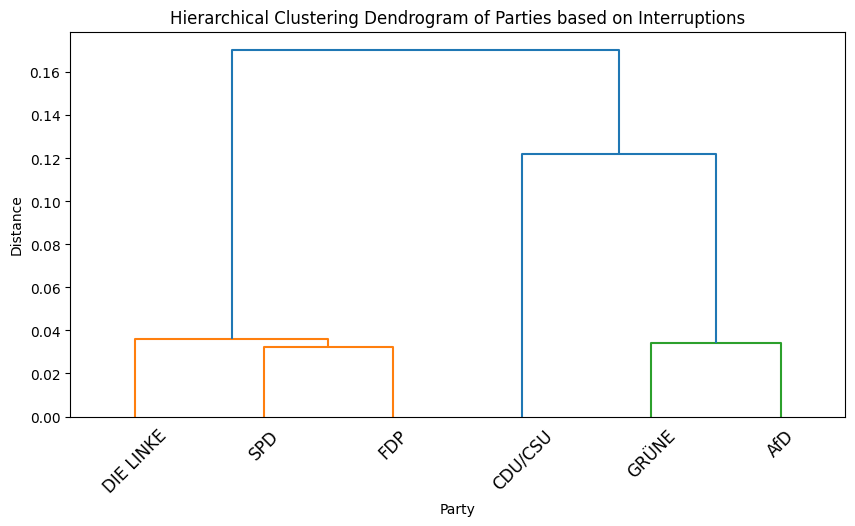

In [175]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np

average_tfidf_vectors_sparse = [csr_matrix.mean(tfidf_vec, axis=0) for tfidf_vec in tfidf_vecs_parties]

# Stack the sparse average vectors into a single sparse matrix
average_tfidf_matrix = csr_matrix(np.vstack(average_tfidf_vectors_sparse))

# Compute the cosine similarity matrix directly on sparse matrices
cosine_sim_matrix_sparse = cosine_similarity(average_tfidf_matrix)

# Convert the cosine similarity matrix to a distance matrix
distance_matrix_sparse = 1 - cosine_sim_matrix_sparse

# Perform hierarchical clustering using the distance matrix
linkage_matrix_sparse = linkage(distance_matrix_sparse[:-1,:-1], method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix_sparse, labels=parties[:-1])  # Exclude 'fraktionslos' as it was removed earlier
plt.title('Hierarchical Clustering Dendrogram of Parties based on Interruptions')
plt.xlabel('Party')
plt.ylabel('Distance')
plt.xticks(rotation=45)
plt.show()

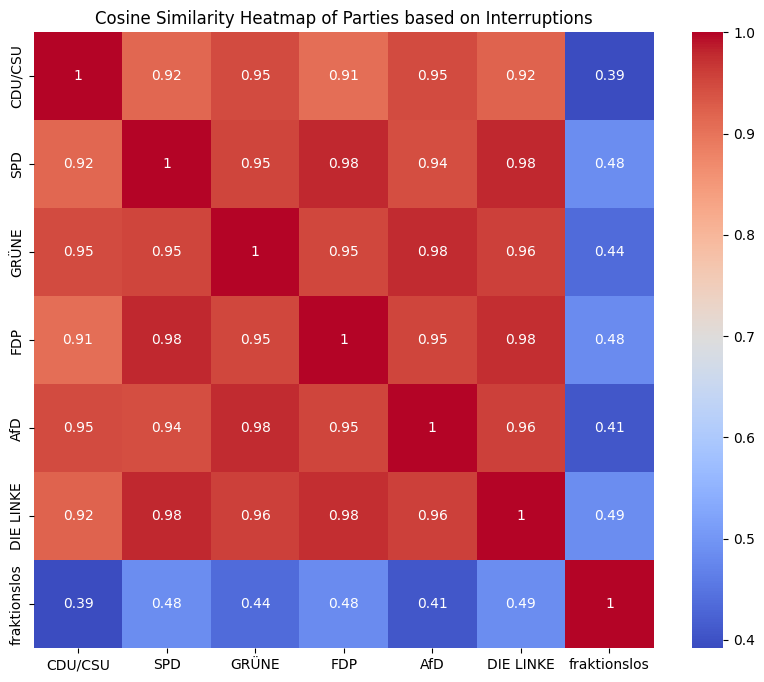

In [170]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_sim_matrix_sparse, xticklabels=parties, yticklabels=parties, cmap='coolwarm', annot=True)
plt.title('Cosine Similarity Heatmap of Parties based on Interruptions')
plt.show()

In [172]:
cosine_sim_matrix_sparse = cosine_sim_matrix_sparse[:-1,:-1]

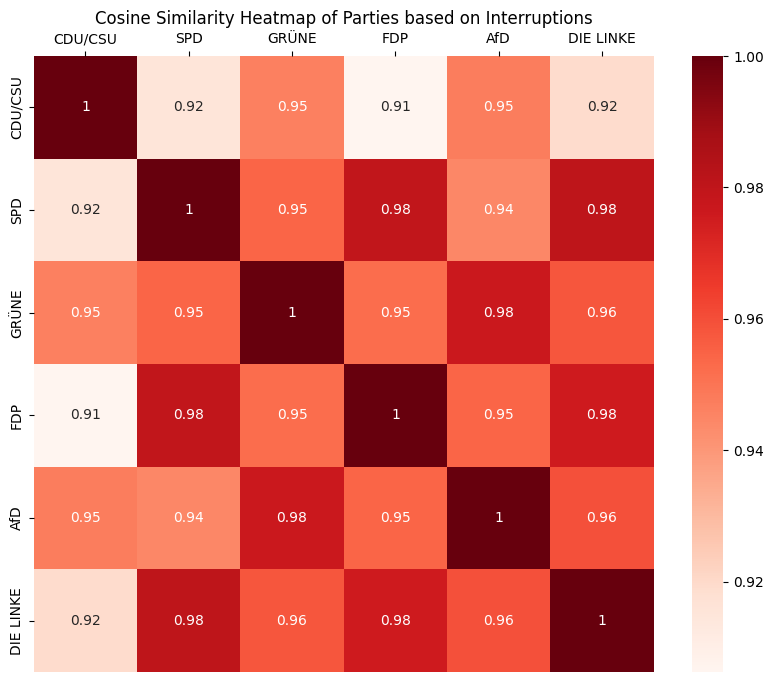

In [173]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cosine_sim_matrix_sparse, xticklabels=parties[:-1], yticklabels=parties[:-1], cmap='Reds', annot=True)

ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')
plt.title('Cosine Similarity Heatmap of Parties based on Interruptions')
plt.show()

In [178]:
texts_per_party_lists = []
start_date, end_date = '2021-09-01', '2024-06-20'
relevant_texts = df_interruptions[(df_interruptions['date']>= start_date)&(df_interruptions['date']<= end_date)]
relevant_texts.groupby('comment_party')['comment_text'].apply(lambda x: texts_per_party_lists.append(x.to_list()))
for l in texts_per_party_lists:
    print (len(l))

16652
24197
2856
5908
11415
10067
29


In [179]:
vectorizer = TfidfVectorizer(stop_words=stop_words, lowercase=True, min_df=3, max_df=0.8)

tfidf_vecs_parties =[]
features_names_parties = []
all_comment_texts =[]
for sublist in texts_per_party_lists:
    all_comment_texts.extend(sublist)

vectorizer.fit(all_comment_texts)
feature_names=vectorizer.get_feature_names_out()
for party_texts in texts_per_party_lists:
    tfidf_vec = vectorizer.transform(party_texts)
    tfidf_vecs_parties.append(tfidf_vec)
    

c:\ProgFiles\PythonVenvs\.NLPvenv\Lib\site-packages\sklearn\feature_extraction\text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ernst', 'ordnung', 'schluss', 'wahr'] not in stop_words.
  warnings.warn(


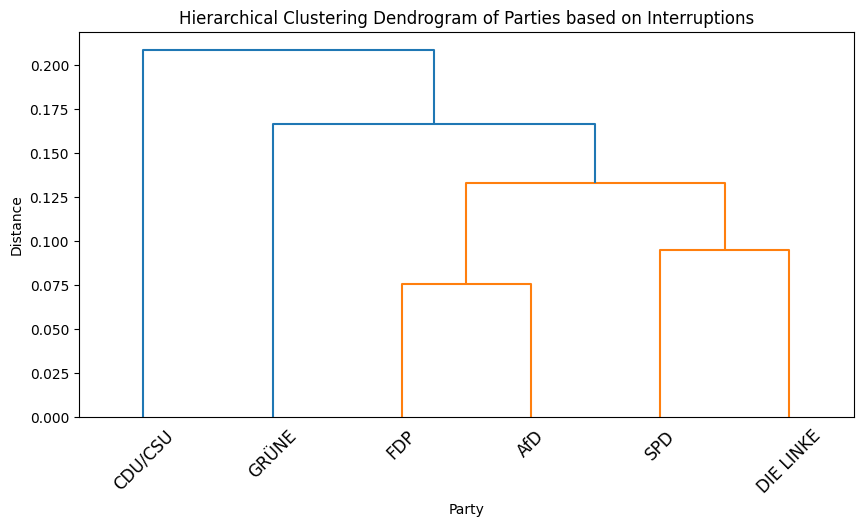

In [180]:
average_tfidf_vectors_sparse = [csr_matrix.mean(tfidf_vec, axis=0) for tfidf_vec in tfidf_vecs_parties]

# Stack the sparse average vectors into a single sparse matrix
average_tfidf_matrix = csr_matrix(np.vstack(average_tfidf_vectors_sparse))

# Compute the cosine similarity matrix directly on sparse matrices
cosine_sim_matrix_sparse = cosine_similarity(average_tfidf_matrix)

# Convert the cosine similarity matrix to a distance matrix
distance_matrix_sparse = 1 - cosine_sim_matrix_sparse

# Perform hierarchical clustering using the distance matrix
linkage_matrix_sparse = linkage(distance_matrix_sparse[:-1,:-1], method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix_sparse, labels=parties[:-1])  # Exclude 'fraktionslos' as it was removed earlier
plt.title('Hierarchical Clustering Dendrogram of Parties based on Interruptions')
plt.xlabel('Party')
plt.ylabel('Distance')
plt.xticks(rotation=45)
plt.show()

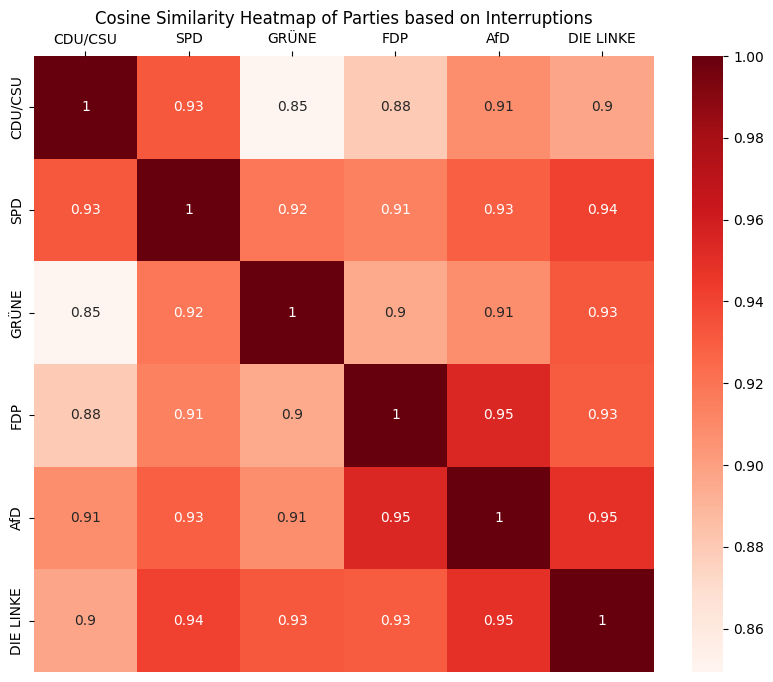

In [185]:
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cosine_sim_matrix_sparse[:-1,:-1], xticklabels=parties[:-1], yticklabels=parties[:-1], cmap='Reds', annot=True)

ax.xaxis.set_label_position('top')
ax.xaxis.set_ticks_position('top')
plt.title('Cosine Similarity Heatmap of Parties based on Interruptions')
plt.show()